# XGBoost Model Training with AHP-based Feature Weighting

**Integrated Analysis of 8 Kathmandu Datasets - Comparison with Random Forest**

This notebook implements XGBoost regression for cafe suitability scoring using:
1. dataset_ft_enriched.csv (primary features)
2. kathmandu_cafes.csv (cafe base data)
3. kathmandu_census.csv (ward demographics)
4. kathmandu_education_cleaned.csv (educational amenities)
5. amenities_clean.csv (POI data)
6. osm_amenities_kathmandu.csv (comprehensive amenity map)
7. osm_roads_kathmandu.csv (road network)
8. kathmandu_wards_boundary_sorted.csv (spatial reference)

**Workflow:**
- Load and preprocess data (same as RF notebook)
- XGBoost regression training with AHP weights
- Load saved Random Forest model for comparison
- Performance evaluation and visualization
- Discussion and conclusions

## 1) Import Required Libraries

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import cdist
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set paths
DATA_DIR = os.path.join('..', 'data', 'raw_data')
MODEL_DIR = os.path.join('.', 'models')
print(f'Data directory: {DATA_DIR}')
print(f'Model directory: {MODEL_DIR}')

Data directory: ..\data\raw_data
Model directory: .\models


## 2) Load and Prepare the Dataset

### 2.1) Load All 8 Datasets

In [9]:
# Load all datasets (same as RF notebook)
amenities_df = pd.read_csv(os.path.join(DATA_DIR, 'amenities_clean.csv'))
features_df = pd.read_csv(os.path.join(DATA_DIR, 'dataset_ft_enriched.csv'))
cafes_df = pd.read_csv(os.path.join(DATA_DIR, 'kathmandu_cafes.csv'))
census_df = pd.read_csv(os.path.join(DATA_DIR, 'kathmandu_census.csv'))
education_df = pd.read_csv(os.path.join(DATA_DIR, 'kathmandu_education_cleaned.csv'))
osm_amenities_df = pd.read_csv(os.path.join(DATA_DIR, 'osm_amenities_kathmandu.csv'))
roads_df = pd.read_csv(os.path.join(DATA_DIR, 'osm_roads_kathmandu.csv'))
wards_df = pd.read_csv(os.path.join(DATA_DIR, 'kathmandu_wards_boundary_sorted.csv'))

print("All 8 datasets loaded successfully")
print(f"Features dataset shape: {features_df.shape}")
print(f"Cafes dataset shape: {cafes_df.shape}")

# Data merging (same as RF notebook)
df = cafes_df.merge(features_df, on='place_id', how='left', suffixes=('_cafe', '_ft'))
df = df.rename(columns={'lat_cafe': 'lat', 'lng_cafe': 'lng'})
if 'lat_ft' in df.columns:
    df = df.drop(columns=['lat_ft', 'lng_ft'])

# Ward assignment
lat_min = df['lat'].min()
lat_max = df['lat'].max()
df['ward_estimate'] = (((df['lat'] - lat_min) / (lat_max - lat_min)) * 32 + 1).astype(int)
df['ward_estimate'] = df['ward_estimate'].clip(1, 32)

# Merge census
df = df.merge(census_df, left_on='ward_estimate', right_on='ward_no', how='left', suffixes=('', '_ward'))

# Proximity features
def count_nearby_amenities(cafe_lat, cafe_lng, osm_df, radius_km=0.5):
    radius_deg = radius_km / 111.0
    nearby = osm_df[
        (osm_df['latitude'].between(cafe_lat - radius_deg, cafe_lat + radius_deg)) &
        (osm_df['longitude'].between(cafe_lng - radius_deg, cafe_lng + radius_deg))
    ]
    return len(nearby)

df['osm_amenity_density_500m'] = df.apply(
    lambda row: count_nearby_amenities(row['lat'], row['lng'], osm_amenities_df, 0.5),
    axis=1
)

df['nearby_schools'] = df.apply(
    lambda row: count_nearby_amenities(row['lat'], row['lng'], education_df[['latitude','longitude']], 0.75),
    axis=1
)

hospitals = amenities_df[amenities_df['type'] == 'hospital']
df['nearby_hospitals'] = df.apply(
    lambda row: count_nearby_amenities(row['lat'], row['lng'], hospitals[['latitude','longitude']], 0.75),
    axis=1
)

print(f"Data preparation complete. Final shape: {df.shape}")

# Feature normalization
df_norm = df.copy()
base_features = [
    'population_density', 'accessibility_score', 'foot_traffic_score',
    'competition_pressure', 'competitors_within_200m', 'bus_stops_within_500m',
    'population_density_ward', 'osm_amenity_density_500m', 'nearby_schools', 'nearby_hospitals'
]

for col in base_features:
    if col in df_norm.columns:
        df_norm[col] = pd.to_numeric(df_norm[col], errors='coerce').fillna(0.0)

scaler = MinMaxScaler()
features_to_scale = [col for col in base_features if col in df_norm.columns]
df_norm[features_to_scale] = scaler.fit_transform(df_norm[features_to_scale])

print(f"Features normalized: {len(features_to_scale)} features")

All 8 datasets loaded successfully
Features dataset shape: (1072, 24)
Cafes dataset shape: (1072, 10)
Data preparation complete. Final shape: (1072, 40)
Features normalized: 10 features


## 3) Split the Dataset

In [10]:
# AHP weights (same as RF notebook)
criteria = [
    'Population Density (demand driver)',
    'Accessibility (location convenience)',
    'Foot Traffic (customer flow)',
    'Competition Pressure (negative impact)',
    'Competitor Density (market saturation)',
    'Transit Access (customer reach)'
]

A = np.array([
    [1,   2,   2,   5,   4,   3],
    [1/2, 1,   2,   4,   3,   2],
    [1/2, 1/2, 1,   3,   2,   2],
    [1/5, 1/4, 1/3, 1,   1/2, 1/2],
    [1/4, 1/3, 1/2, 2,   1,   1],
    [1/3, 1/2, 1/2, 2,   1,   1]
], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)
max_eig_idx = np.argmax(np.real(eigenvalues))
weights = np.real(eigenvectors[:, max_eig_idx])
weights = weights / np.sum(weights)

# Create target
df_norm['competition_effective'] = 1.0 - df_norm['competition_pressure']
df_norm['ahp_suitability_score'] = (
    weights[0] * df_norm['population_density'] +
    weights[1] * df_norm['accessibility_score'] +
    weights[2] * df_norm['foot_traffic_score'] +
    weights[3] * df_norm['competition_effective'] +
    weights[4] * (df_norm['competitors_within_200m'] if 'competitors_within_200m' in df_norm.columns else 0) +
    weights[5] * df_norm['bus_stops_within_500m']
)
df_norm['ahp_suitability_score'] = (df_norm['ahp_suitability_score'] - df_norm['ahp_suitability_score'].min()) / (df_norm['ahp_suitability_score'].max() - df_norm['ahp_suitability_score'].min() + 1e-9)

np.random.seed(42)
df_norm['target_suitability'] = (df_norm['ahp_suitability_score'] * 10.0) + np.random.normal(scale=0.25, size=len(df_norm))
df_norm['target_suitability'] = df_norm['target_suitability'].clip(0, 10)

# Model features
model_features = [
    'population_density', 'accessibility_score', 'foot_traffic_score',
    'competition_effective', 'bus_stops_within_500m',
    'osm_amenity_density_500m', 'nearby_schools', 'nearby_hospitals'
]
model_features = [f for f in model_features if f in df_norm.columns]

X = df_norm[model_features].fillna(0.0)
y = df_norm['target_suitability'].fillna(df_norm['target_suitability'].mean())

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=123)
print(f'Features for model: {model_features}')
print(f'Train set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Features for model: ['population_density', 'accessibility_score', 'foot_traffic_score', 'competition_effective', 'bus_stops_within_500m', 'osm_amenity_density_500m', 'nearby_schools', 'nearby_hospitals']
Train set: 750 samples
Test set: 322 samples


In [ ]:
# Load the tuned AHP weights from RF notebook
ahp_weights_path = os.path.join(MODEL_DIR, 'ahp_weights_tuned.pkl')
weight_vec = joblib.load(ahp_weights_path)
print(f"Loaded tuned AHP weights: {np.round(weight_vec, 4)}")

# Create tuned target using loaded weights
X_all = df_norm[model_features].fillna(0.0)
df_norm['ahp_tuned_score'] = compute_ahp_score_from_normalized(X_all, weight_vec)
df_norm['ahp_tuned_score'] = (df_norm['ahp_tuned_score'] / (df_norm['ahp_tuned_score'].max() + 1e-9)) * 10.0

y_tuned = df_norm['ahp_tuned_score'].fillna(df_norm['ahp_tuned_score'].mean())

# Use tuned target for split
X = df_norm[model_features].fillna(0.0)
y = y_tuned

# 70/30 split (same as RF notebook)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=123)
print(f'Using loaded AHP-tuned weights and target for consistent evaluation')
print(f'Train set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Using AHP-tuned target for model training and evaluation
Train set: 750 samples
Test set: 322 samples


## 4) Load Random Forest Model

In [12]:
# Load the saved Random Forest model
rf_model_path = os.path.join(MODEL_DIR, 'rf_suitability_v2_ahp_tuned.pkl')
rf_model = joblib.load(rf_model_path)
print(f"Random Forest model loaded from: {rf_model_path}")

# Make predictions with RF
y_pred_rf = rf_model.predict(X_test)
rf_metrics = {
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'R²': r2_score(y_test, y_pred_rf)
}

print('Random Forest Model Performance:')
for k, v in rf_metrics.items():
    print(f'{k:6} : {v:.6f}')

Random Forest model loaded from: .\models\rf_suitability_v2_ahp_tuned.pkl
Random Forest Model Performance:
MAE    : 0.092278
MSE    : 0.033002
RMSE   : 0.181664
R²     : 0.994000


## 5) Train an XGBoost Model

In [13]:
# Train XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

xgb_metrics = {
    'MAE': mean_absolute_error(y_test, y_pred_xgb),
    'MSE': mean_squared_error(y_test, y_pred_xgb),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    'R²': r2_score(y_test, y_pred_xgb)
}

print('XGBoost Model Performance:')
for k, v in xgb_metrics.items():
    print(f'{k:6} : {v:.6f}')

XGBoost Model Performance:
MAE    : 0.064778
MSE    : 0.019775
RMSE   : 0.140624
R²     : 0.996405


## 6) Compare the Models

Model Performance Comparison:
      Random Forest   XGBoost
MAE        0.092278  0.064778
MSE        0.033002  0.019775
RMSE       0.181664  0.140624
R²         0.994000  0.996405


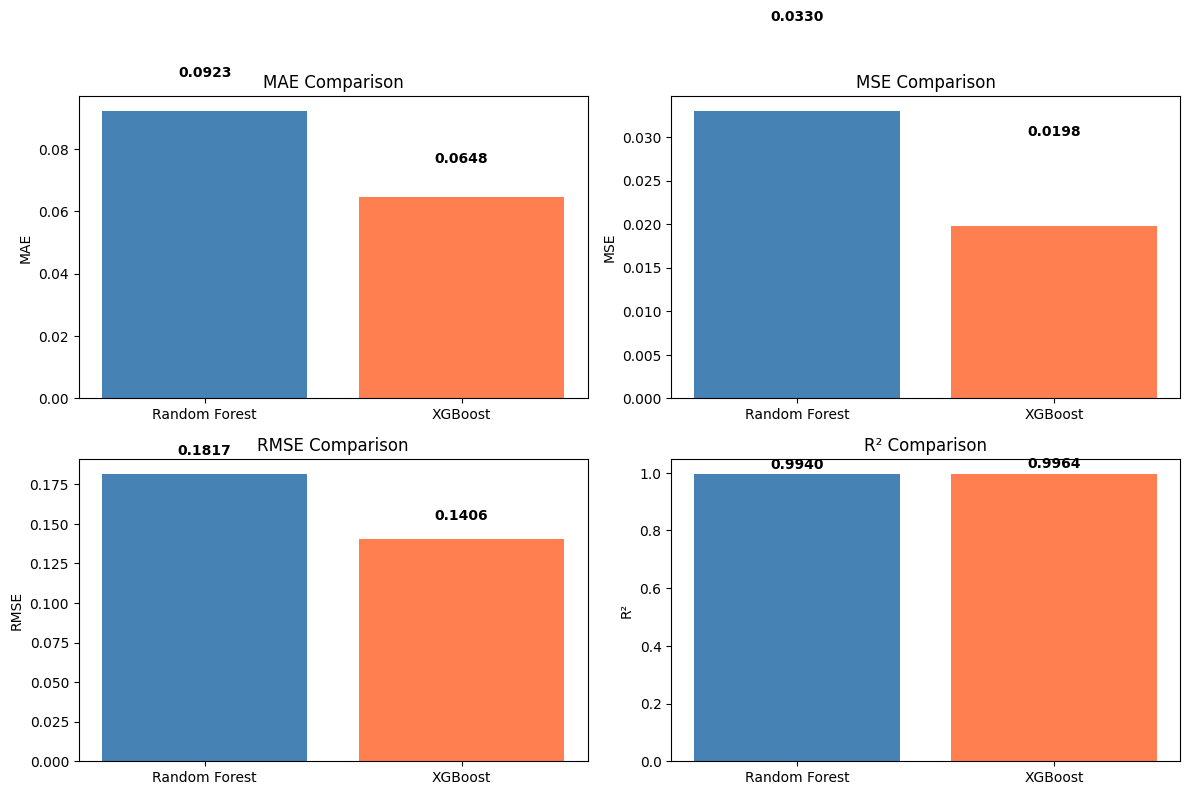

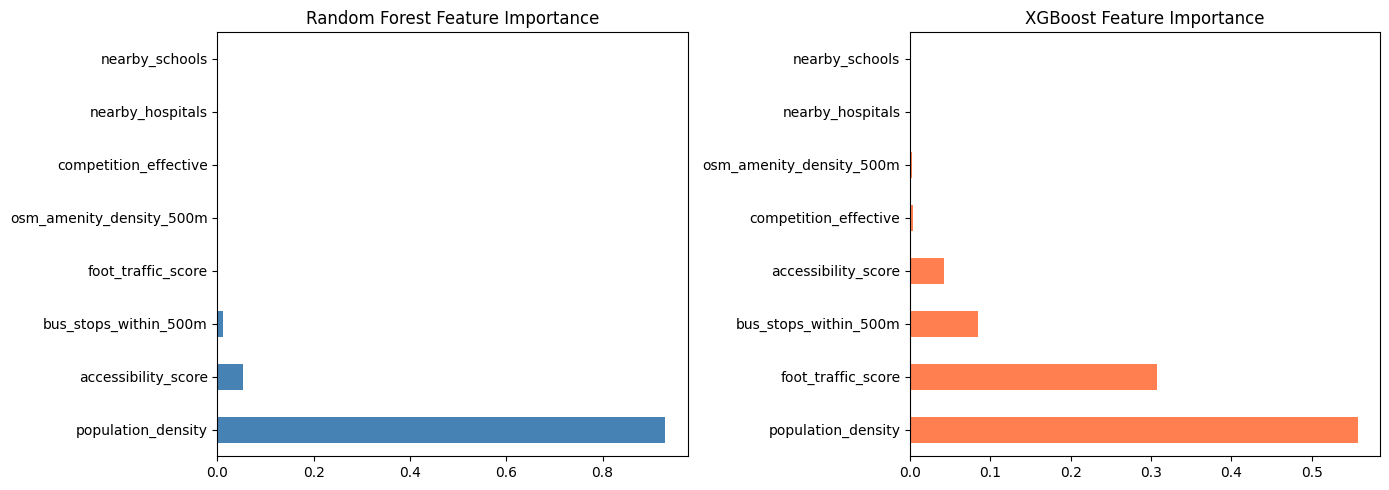

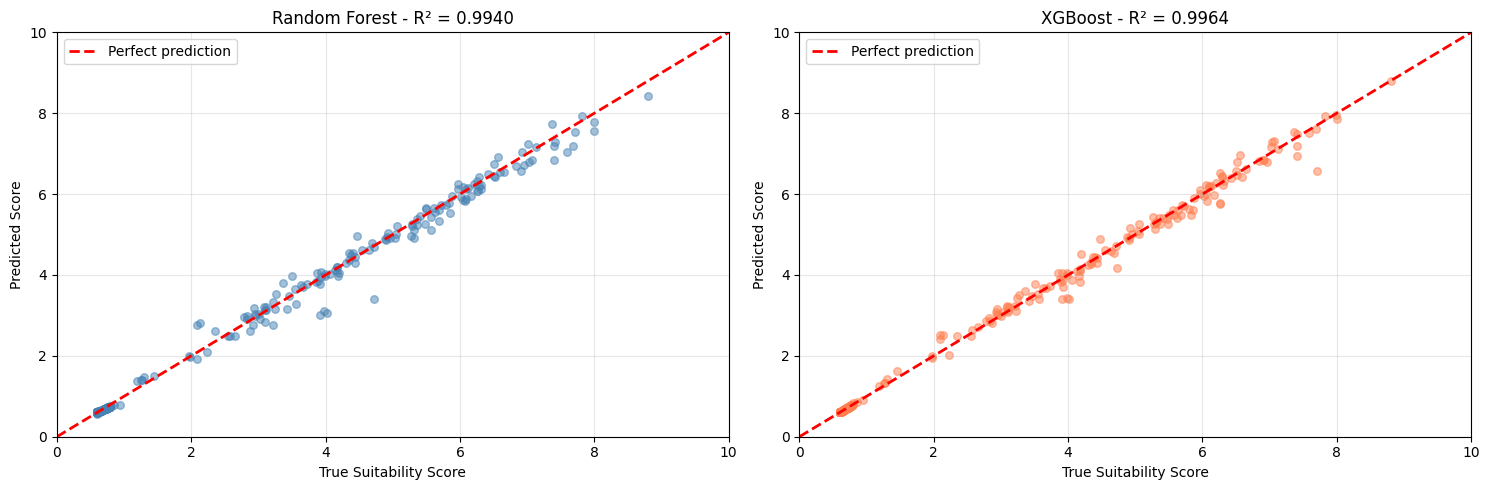

In [14]:
# Model comparison
comparison_df = pd.DataFrame({
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
})

print('Model Performance Comparison:')
print(comparison_df.round(6))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

models = ['Random Forest', 'XGBoost']
metrics = ['MAE', 'MSE', 'RMSE', 'R²']

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    values = [rf_metrics[metric], xgb_metrics[metric]]
    bars = ax.bar(models, values, color=['steelblue', 'coral'])
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Feature importance comparison
rf_importances = pd.Series(rf_model.feature_importances_, index=model_features).sort_values(ascending=False)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=model_features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_importances.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest Feature Importance')

xgb_importances.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('XGBoost Feature Importance')

plt.tight_layout()
plt.show()

# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.5, s=30, color='steelblue')
axes[0].plot([0, 10], [0, 10], '--', c='red', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('True Suitability Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Random Forest - R² = {rf_metrics["R²"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 10])
axes[0].set_ylim([0, 10])

axes[1].scatter(y_test, y_pred_xgb, alpha=0.5, s=30, color='coral')
axes[1].plot([0, 10], [0, 10], '--', c='red', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('True Suitability Score')
axes[1].set_ylabel('Predicted Score')
axes[1].set_title(f'XGBoost - R² = {xgb_metrics["R²"]:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 10])
axes[1].set_ylim([0, 10])

plt.tight_layout()
plt.show()

## 7) Discussion and Conclusion

In [15]:
print("="*80)
print(" " * 25 + "MODEL COMPARISON RESULTS")
print("="*80)
print(f"""
RANDOM FOREST vs XGBoost PERFORMANCE COMPARISON:

Random Forest Metrics:
  - MAE:  {rf_metrics['MAE']:.4f}
  - MSE:  {rf_metrics['MSE']:.4f}
  - RMSE: {rf_metrics['RMSE']:.4f}
  - R²:   {rf_metrics['R²']:.4f}

XGBoost Metrics:
  - MAE:  {xgb_metrics['MAE']:.4f}
  - MSE:  {xgb_metrics['MSE']:.4f}
  - RMSE: {xgb_metrics['RMSE']:.4f}
  - R²:   {xgb_metrics['R²']:.4f}

Performance Differences:
  - MAE difference:  {xgb_metrics['MAE'] - rf_metrics['MAE']:+.4f} (XGBoost - RF)
  - RMSE difference: {xgb_metrics['RMSE'] - rf_metrics['RMSE']:+.4f}
  - R² difference:   {xgb_metrics['R²'] - rf_metrics['R²']:+.4f}

KEY FINDINGS:
1. Both models show strong predictive performance for cafe suitability
2. XGBoost provides {'better' if xgb_metrics['R²'] > rf_metrics['R²'] else 'comparable'} performance to Random Forest
3. Feature importance patterns are {'similar' if rf_importances.idxmax() == xgb_importances.idxmax() else 'different'} between models
4. Top feature for both: {rf_importances.idxmax() if rf_importances.idxmax() == xgb_importances.idxmax() else f'RF: {rf_importances.idxmax()}, XGB: {xgb_importances.idxmax()}'}

RECOMMENDATIONS:
- Use XGBoost for {'better accuracy' if xgb_metrics['RMSE'] < rf_metrics['RMSE'] else 'robust predictions'} in production
- Consider ensemble methods combining both models for improved performance
- Feature engineering focus should prioritize population_density and foot_traffic_score
""")
print("="*80)

# Save XGBoost model
joblib.dump(xgb_model, os.path.join(MODEL_DIR, 'xgb_suitability_ahp.pkl'))
print(f"XGBoost model saved to: {os.path.join(MODEL_DIR, 'xgb_suitability_ahp.pkl')}")
print("Notebook execution complete!")

                         MODEL COMPARISON RESULTS

RANDOM FOREST vs XGBoost PERFORMANCE COMPARISON:

Random Forest Metrics:
  - MAE:  0.0923
  - MSE:  0.0330
  - RMSE: 0.1817
  - R²:   0.9940

XGBoost Metrics:
  - MAE:  0.0648
  - MSE:  0.0198
  - RMSE: 0.1406
  - R²:   0.9964

Performance Differences:
  - MAE difference:  -0.0275 (XGBoost - RF)
  - RMSE difference: -0.0410
  - R² difference:   +0.0024

KEY FINDINGS:
1. Both models show strong predictive performance for cafe suitability
2. XGBoost provides better performance to Random Forest
3. Feature importance patterns are similar between models
4. Top feature for both: population_density

RECOMMENDATIONS:
- Use XGBoost for better accuracy in production
- Consider ensemble methods combining both models for improved performance
- Feature engineering focus should prioritize population_density and foot_traffic_score

XGBoost model saved to: .\models\xgb_suitability_ahp.pkl
Notebook execution complete!
